combine af3, bipspi, pyrosetta features

In [ ]:
import os
import json
import zipfile
import pandas as pd
import numpy as np
from tqdm import tqdm
from google.colab import drive

# 1. SETUP & PATHS
drive.mount('/content/drive', force_remount=True)

BASE_PATH = '/content/drive/Shared drives/CMU Zymo Capstone S26'
AF3_DIR = os.path.join(BASE_PATH, "15seed_AF3")
BIPSPI_ROOT = os.path.join(BASE_PATH, "BIPSPI_outputs")
ROSETTA_FILE = os.path.join(BASE_PATH, "pyRosetta/output_binding_energies.csv")
# Saving as V13 to distinguish this full-feature version
OUTPUT_FILE = os.path.join(BASE_PATH, "FINAL_INTEGRATED_DATA_V13.csv")

def get_pdb_code(text):
    import re
    if not isinstance(text, str): return None
    match = re.search(r'([0-9][A-Z0-9]{3})', text.upper())
    return match.group(1) if match else None

# 2. PRE-LOAD EXTERNAL DATA
print("📂 Indexing BIPSPI results...")
bipspi_db = {}
if os.path.exists(BIPSPI_ROOT):
    for root, dirs, files in os.walk(BIPSPI_ROOT):
        pdb = get_pdb_code(os.path.basename(root))
        if not pdb: continue
        for fn in files:
            if fn in ['PRED.res.tab.gz', 'PRED.res.tab']:
                try:
                    b_df = pd.read_table(os.path.join(root, fn), sep=r'\s+', compression='gzip' if 'gz' in fn else None)
                    bipspi_db[pdb] = {
                        'L': b_df.groupby('resIdL')['prediction'].max().to_dict(),
                        'R': b_df.groupby('resIdR')['prediction'].max().to_dict()
                    }
                except: continue

print("📂 Indexing Rosetta Binding Energies...")
rosetta_map = {}
if os.path.exists(ROSETTA_FILE):
    rdf = pd.read_csv(ROSETTA_FILE)
    for _, row in rdf.iterrows():
        pdb = get_pdb_code(str(row.get('Proteins', '')))
        if pdb:
            rosetta_map[pdb] = row.get('del_G_B', np.nan)

# 3. HELPER FUNCTION TO PROCESS DATA
def process_af3_data(pdb, l_json, j_json, s_json, r_map, b_db):
    rows = []
    seq_list = []
    for entry in j_json[0]['sequences']:
        if 'proteinChain' in entry: seq_list.append(entry['proteinChain']['sequence'])
        elif 'rnaChain' in entry: seq_list.append(entry['rnaChain']['sequence'])

    t_chains = l_json['token_chain_ids']
    t_res = l_json['token_res_ids']
    plddt = l_json.get('token_plddt', l_json.get('atom_plddts', [np.nan]*len(t_chains)))
    pae = np.array(l_json.get('pae', []))
    contact = np.array(l_json.get('contact_probs', []))

    unique_cids = sorted(list(set(t_chains)))
    cid_to_idx = {cid: i for i, cid in enumerate(unique_cids)}

    b_score_map = {}
    if pdb in b_db:
        for side, chains in [('L', unique_cids[:-1]), ('R', [unique_cids[-1]])]:
            offset = 0
            for c in chains:
                c_len = len([tid for tid in t_chains if tid == c])
                for r_id in range(1, c_len + 1):
                    b_score_map[(c, r_id)] = b_db[pdb][side].get(offset + r_id - 1, 0)
                offset += c_len

    complex_dg = r_map.get(pdb, np.nan)

    for i in range(len(t_chains)):
        c_val, r_id = t_chains[i], int(t_res[i])
        c_idx = cid_to_idx[c_val]
        try: aa = seq_list[c_idx][r_id - 1]
        except: aa = 'X'

        # Identify indices of tokens belonging to DIFFERENT chains
        others = [j for j, val in enumerate(t_chains) if val != c_val]

        # Local AF3 Features (Inter-chain confidence)
        ipae_min = np.min(pae[i, others]) if others and pae.size > 0 else np.nan
        ipae_mean = np.mean(pae[i, others]) if others and pae.size > 0 else np.nan
        cp_max = np.max(contact[i, others]) if others and contact.size > 0 else 0

        rows.append({
            'complex_id': pdb,
            'chain': chr(65 + c_idx),
            'residue': r_id,
            'amino_acid': aa,
            # AF3 Local Features
            'af3_plddt': plddt[i],
            'af3_ipae_min': ipae_min,
            'af3_ipae_mean': ipae_mean,
            'af3_contact_prob_max': cp_max,
            # AF3 Global Features
            'iptm': s_json.get('iptm', 0),
            'ptm': s_json.get('ptm', 0),
            'ranking_score': s_json.get('ranking_score', 0),
            # External Features
            'rosetta_dg': complex_dg,
            'bipspi_score': b_score_map.get((c_val, r_id), 0)
        })
    return rows

# 4. MAIN DEEP-SCAN LOOP
print(f"📂 Deep-scanning {AF3_DIR}...")
all_rows = []
zip_files = [f for f in os.listdir(AF3_DIR) if f.endswith('.zip')]

for z_fn in tqdm(zip_files, desc="Zips"):
    z_path = os.path.join(AF3_DIR, z_fn)
    with zipfile.ZipFile(z_path, 'r') as z:
        files_by_dir = {}
        for name in z.namelist():
            parent = os.path.dirname(name)
            if parent not in files_by_dir: files_by_dir[parent] = []
            files_by_dir[parent].append(name)

        for folder, contents in files_by_dir.items():
            f_json = [c for c in contents if 'full_data_0.json' in c]
            j_json = [c for c in contents if 'job_request.json' in c]
            s_json = [c for c in contents if 'summary_confidences_0.json' in c]

            if f_json and j_json and s_json:
                try:
                    pdb = get_pdb_code(folder) or get_pdb_code(z_fn)
                    with z.open(f_json[0]) as f: ld = json.load(f)
                    with z.open(j_json[0]) as f: jd = json.load(f)
                    with z.open(s_json[0]) as f: sd = json.load(f)

                    complex_rows = process_af3_data(pdb, ld, jd, sd, rosetta_map, bipspi_db)
                    all_rows.extend(complex_rows)
                except Exception as e:
                    continue

# 5. EXPORT
if all_rows:
    df = pd.DataFrame(all_rows)
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"\n✅ SUCCESS!")
    print(f"📊 Processed {df['complex_id'].nunique()} unique complexes.")
    print(f"📁 Total data rows: {len(df)}")
    print(f"📝 Features integrated: {list(df.columns)}")
else:
    print("❌ No data found.")

Mounted at /content/drive
📂 Indexing BIPSPI results...
📂 Indexing Rosetta Binding Energies...
📂 Deep-scanning /content/drive/Shared drives/CMU Zymo Capstone S26/15seed_AF3...


Zips: 100%|██████████| 3/3 [00:23<00:00,  7.90s/it]



✅ SUCCESS!
📊 Processed 103 unique complexes.
📁 Total data rows: 33902
📝 Features integrated: ['complex_id', 'chain', 'residue', 'amino_acid', 'af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max', 'iptm', 'ptm', 'ranking_score', 'rosetta_dg', 'bipspi_score']


get esm2 embeddings

In [7]:
from google.colab import drive
import os

# This forces Colab to re-index the files in your Drive
drive.mount('/content/drive', force_remount=True)

# Define the path again to be safe
BASE_PATH = '/content/drive/Shared drives/CMU Zymo Capstone S26'
INPUT_FILE = os.path.join(BASE_PATH, "FINAL_INTEGRATED_DATA.csv")

# Verify the file is actually visible to the script before proceeding
if os.path.exists(INPUT_FILE):
    print("✅ File found! Proceeding...")
else:
    print("❌ Still not found. Checking directory content...")
    print(os.listdir(BASE_PATH))

Mounted at /content/drive
✅ File found! Proceeding...


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from google.colab import drive
from transformers import AutoTokenizer, EsmModel

# 1. MOUNT DRIVE & SETUP PATHS
drive.mount('/content/drive', force_remount=True)

BASE_PATH = '/content/drive/Shared drives/CMU Zymo Capstone S26'
# Using the integrated V12 file from the previous step
INPUT_FILE = os.path.join(BASE_PATH, "FINAL_INTEGRATED_DATA.csv")
OUTPUT_CSV = os.path.join(BASE_PATH, "ESM_READY_DATA.csv")
OUTPUT_NPY = os.path.join(BASE_PATH, "esm2_embeddings_650M.npy")

# 2. LOAD MODEL (Hugging Face Transformers)
model_name = "facebook/esm2_t33_650M_UR50D"
print(f"🚀 Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name)

# Use GPU and Half-Precision (FP16) for speed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
if torch.cuda.is_available():
    model = model.half() # Use FP16 only if on GPU
model.eval()

# 3. PREPARE SEQUENCES
df = pd.read_csv(INPUT_FILE)
# Group by complex and chain to reconstruct the sequences
complex_groups = df.groupby(['complex_id', 'chain'])['amino_acid'].apply(lambda x: "".join(x.astype(str))).reset_index()

# This dictionary stores the matrix for each unique chain
embedding_dict = {}

# 4. GENERATION LOOP
print(f"🧠 Generating Embeddings on {device}...")
with torch.no_grad():
    for _, row in tqdm(complex_groups.iterrows(), total=len(complex_groups)):
        cid = row['complex_id']
        chn = row['chain']
        sequence = row['amino_acid']

        # Tokenize sequence
        inputs = tokenizer(sequence, return_tensors="pt", padding=False, truncation=False)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Forward pass
        outputs = model(**inputs)

        # Get hidden states: [1, seq_len + 2, 1280]
        # Remove CLS (index 0) and EOS (last index) to match original sequence length
        full_matrix = outputs.last_hidden_state.cpu().numpy()
        seq_embeddings = full_matrix[0, 1:-1, :]

        embedding_dict[(cid, chn)] = seq_embeddings.astype(np.float32)

# 5. ALIGNMENT STEP (Mapping back to every row in the original CSV)
print("🔗 Aligning embeddings to master CSV rows...")
final_list = []
valid_indices = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    key = (row['complex_id'], row['chain'])
    # AF3 residues are 1-indexed, so we subtract 1 for the list index
    res_idx = int(row['residue']) - 1

    try:
        # Pull the specific 1280-d vector for this exact residue
        res_vector = embedding_dict[key][res_idx]
        final_list.append(res_vector)
        valid_indices.append(i)
    except (IndexError, KeyError):
        # This handles cases where sequence data might be missing or mismatched
        continue

# 6. SAVE TO DRIVE
final_matrix = np.array(final_list)
np.save(OUTPUT_NPY, final_matrix)

# Save the updated CSV (ensures rows match the .npy perfectly)
df_final = df.iloc[valid_indices].copy()
df_final.to_csv(OUTPUT_CSV, index=False)

print("\n" + "="*40)
print(f"✅ SUCCESSFUL EXPORT")
print(f"📍 Matrix Location: {OUTPUT_NPY}")
print(f"📍 CSV Location: {OUTPUT_CSV}")
print(f"📊 Final Shape: {final_matrix.shape}")
print("="*40)

Mounted at /content/drive
🚀 Loading facebook/esm2_t33_650M_UR50D...


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🧠 Generating Embeddings on cpu...


100%|██████████| 223/223 [19:56<00:00,  5.37s/it]


🔗 Aligning embeddings to master CSV rows...


100%|██████████| 33902/33902 [00:02<00:00, 16823.53it/s]



✅ SUCCESSFUL EXPORT
📍 Matrix Location: /content/drive/Shared drives/CMU Zymo Capstone S26/esm2_embeddings_650M.npy
📍 CSV Location: /content/drive/Shared drives/CMU Zymo Capstone S26/ESM_READY_DATA.csv
📊 Final Shape: (33902, 1280)


Get ground truth labels

In [ ]:
!pip install biopython

import os
import pandas as pd
import numpy as np
from Bio.PDB import PDBList, PDBParser, NeighborSearch
from tqdm import tqdm
from google.colab import drive

# 1. SETUP
drive.mount('/content/drive', force_remount=True)
BASE_PATH = '/content/drive/Shared drives/CMU Zymo Capstone S26'
INPUT_FILE = os.path.join(BASE_PATH, "ESM_READY_DATA.csv")
OUTPUT_FILE = os.path.join(BASE_PATH, "FINAL_TRAINING_DATA_WITH_LABELS.csv")
PDB_DIR = os.path.join(BASE_PATH, "experimental_pdbs")
os.makedirs(PDB_DIR, exist_ok=True)

pdbl = PDBList()
parser = PDBParser(QUIET=True)
df = pd.read_csv(INPUT_FILE)

# 2. INTERFACE CALCULATION FUNCTION
def get_interface_residues(pdb_id, cutoff=5.0):
    """Downloads PDB and identifies residues within 'cutoff' distance of a different chain."""
    file_path = pdbl.retrieve_pdb_file(pdb_id, pdir=PDB_DIR, file_format='pdb')
    structure = parser.get_structure(pdb_id, file_path)
    model = structure[0]

    atoms = [a for a in model.get_atoms()]
    ns = NeighborSearch(atoms)

    interface_map = {} # (chain, res_id) -> bool

    # Initialize all to False
    for chain in model:
        for residue in chain:
            interface_map[(chain.id, residue.get_id()[1])] = 0

    # Search for contacts between different chains
    for atom in atoms:
        chain_id = atom.get_parent().get_parent().id
        neighbors = ns.search(atom.coord, cutoff)
        for neighbor in neighbors:
            neighbor_chain_id = neighbor.get_parent().get_parent().id
            if chain_id != neighbor_chain_id:
                res = atom.get_parent()
                interface_map[(chain_id, res.get_id()[1])] = 1
                break

    return interface_map

# 3. PROCESSING LOOP
print("🔬 Calculating Ground Truth labels from experimental structures...")
all_labels = []
unique_pdbs = df['complex_id'].unique()
master_map = {}

for pdb in tqdm(unique_pdbs):
    try:
        master_map[pdb] = get_interface_residues(pdb)
    except Exception as e:
        print(f"⚠️ Could not process PDB {pdb}: {e}")
        master_map[pdb] = {}

# Map labels back to the main dataframe
for i, row in tqdm(df.iterrows(), total=len(df), desc="Mapping"):
    pdb = row['complex_id']
    chn = row['chain']
    res = int(row['residue'])

    # Default to 0 if PDB data is missing
    label = master_map.get(pdb, {}).get((chn, res), 0)
    all_labels.append(label)

df['ground_truth'] = all_labels

# 4. SAVE
df.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Ground truth labels generated. Interface residues found: {df['ground_truth'].sum()}")

Mounted at /content/drive
🔬 Calculating Ground Truth labels from experimental structures...


  0%|          | 0/103 [00:00<?, ?it/s]

Structure exists: '/content/drive/Shared drives/CMU Zymo Capstone S26/experimental_pdbs/pdb1z0k.ent' 


  1%|          | 1/103 [00:00<00:14,  7.07it/s]

Structure exists: '/content/drive/Shared drives/CMU Zymo Capstone S26/experimental_pdbs/pdb3h2v.ent' 


...

Structure exists: '/content/drive/Shared drives/CMU Zymo Capstone S26/experimental_pdbs/pdb2i9b.ent' 


 99%|█████████▉| 102/103 [00:25<00:00,  4.39it/s]

Structure exists: '/content/drive/Shared drives/CMU Zymo Capstone S26/experimental_pdbs/pdb1ewy.ent' 
Structure exists: '/content/drive/Shared drives/CMU Zymo Capstone S26/experimental_pdbs/pdb1nw9.ent' 


Mapping: 100%|██████████| 33902/33902 [00:02<00:00, 16598.01it/s]


✅ Ground truth labels generated. Interface residues found: 4729


In [4]:
from google.colab import drive
import os

# 1. Mount Google Drive
# This will prompt you for a pairing code to access your Shared Drives
drive.mount('/content/drive', force_remount=True)

# 2. Define the Base Path
# Adjust the name if the Shared Drive name is slightly different
BASE_PATH = '/content/drive/Shared drives/CMU Zymo Capstone S26'

# 3. Verify the connection
if os.path.exists(BASE_PATH):
    print(f"✅ Drive mounted successfully!")
    print("Files in directory:", os.listdir(BASE_PATH))
else:
    print("❌ Drive not found. Please check the Shared Drive name in BASE_PATH.")

Mounted at /content/drive
✅ Drive mounted successfully!
Files in directory: ['Progress_Meeting_Slides', 'Chamy - Background Review Baseline Pipeline.gdoc', 'ProteinPairDataExtraction.py', 'Protein Pair Preliminary Data .gdoc', 'Dataset', 'PDB Files from AF2 Output', 'BIPSPI_outputs', '[Spring 2026] CB Capstone Notes.gdoc', 'AF3 Outputs', 'pyRosetta', 'new_bipspi', '15seed_AF3', 'experimental_pdbs', 'FINAL_INTEGRATED_DATA.csv', 'esm2_embeddings_650M.npy', 'ESM_READY_DATA.csv', 'FINAL_TRAINING_DATA_WITH_LABELS.csv', 'PROTEIN INTERFACE PREDICTION PIPELINE.gdoc', 'Copy of FullPipeline.ipynb']


📂 Loading data for Targeted Validation on 7CZX...
🧬 Reducing ESM-2 to 32 Dimensions...
🚀 Training Ensemble Model with 9 features + ESM-2...


/tmp/ipykernel_3605/2215384727.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
/tmp/ipykernel_3605/2215384727.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Importance', y='Category', data=cat_fi_df, palette='magma')


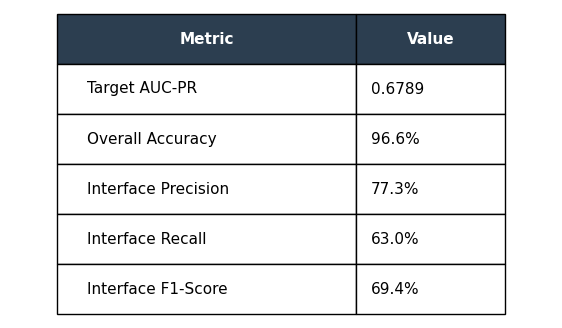

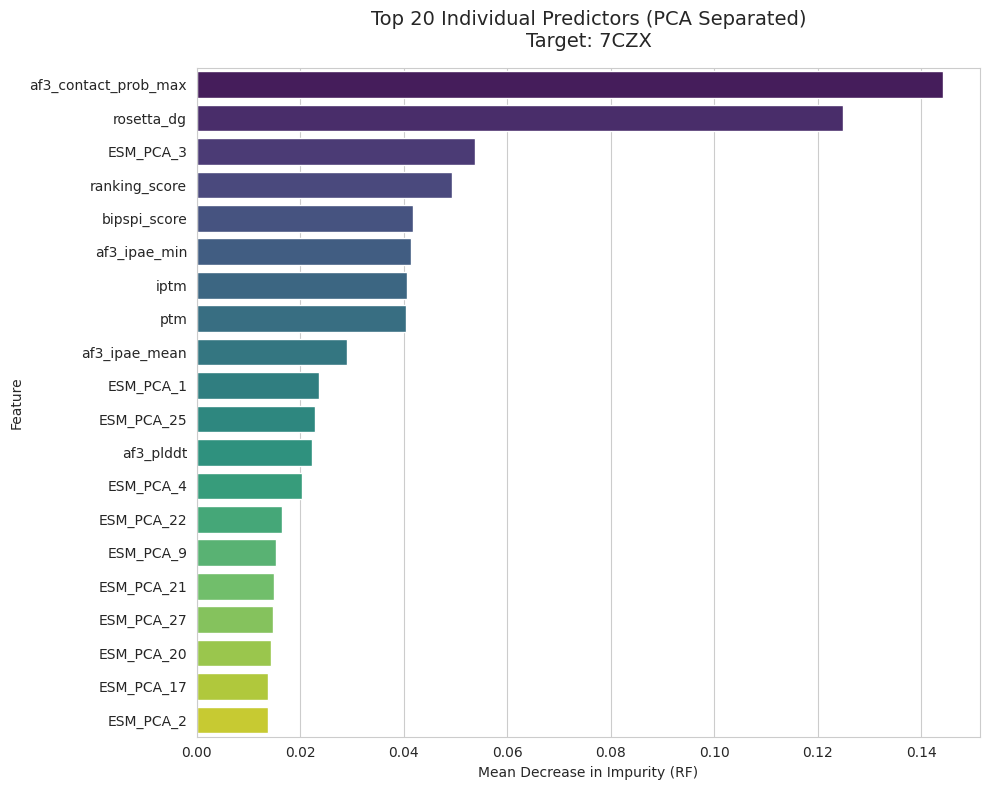

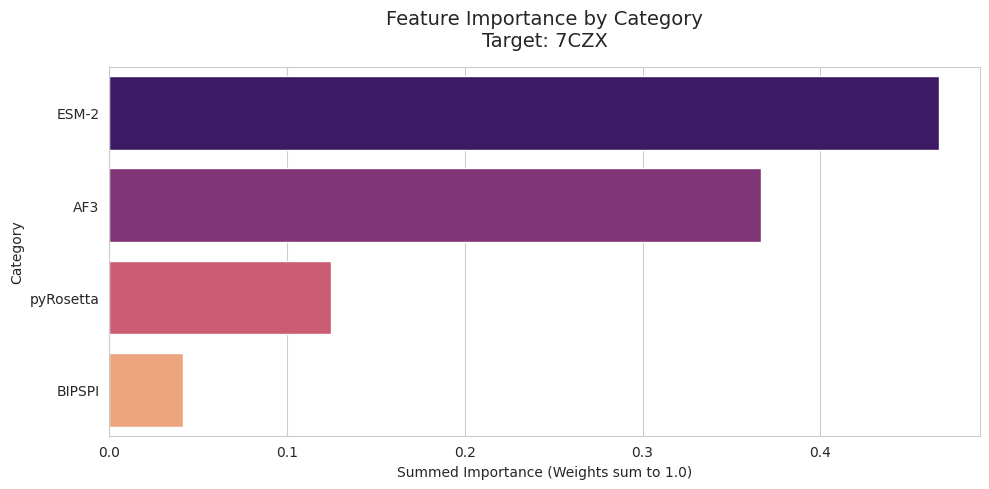


✅ ANALYSIS COMPLETE FOR 7CZX
📊 Metrics: Performance_Final_7CZX.png
📊 Individual Imp: Individual_Importance_Detailed_7CZX.png
📊 Category Imp: Category_Importance_7CZX.png


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (auc, roc_auc_score, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)

# ==========================================
# 1. SETUP & TARGET SELECTION
# ==========================================
TARGET_COMPLEX = "7CZX"
BASE_PATH = '/content/drive/Shared drives/CMU Zymo Capstone S26'
# Ensure this path matches your labeled integrated CSV
CSV_PATH = os.path.join(BASE_PATH, "FINAL_TRAINING_DATA_WITH_LABELS.csv")
NPY_PATH = os.path.join(BASE_PATH, "esm2_embeddings_650M.npy")

print(f"📂 Loading data for Targeted Validation on {TARGET_COMPLEX}...")
df = pd.read_csv(CSV_PATH)
raw_esm = np.load(NPY_PATH)

# Feature Definitions
af3_local = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max']
af3_global = ['iptm', 'ptm', 'ranking_score']
bio_feats = ['rosetta_dg', 'bipspi_score']

feature_cols = af3_local + af3_global + bio_feats

# ==========================================
# 2. PREPROCESSING & PCA
# ==========================================
# Drop rows where ground truth or critical features are missing
mask = df['ground_truth'].notnull() & df['af3_plddt'].notnull()
df_c = df[mask].copy()
esm_c = raw_esm[mask]

# Normalize Numerical Features
scaler = StandardScaler()
df_c[feature_cols] = scaler.fit_transform(df_c[feature_cols])

print(f"🧬 Reducing ESM-2 to 32 Dimensions...")
pca = PCA(n_components=32, random_state=42)
esm_pca = pca.fit_transform(esm_c)
esm_labels = [f'ESM_PCA_{i+1}' for i in range(32)]

X = np.hstack([df_c[feature_cols].values, esm_pca])
y = df_c['ground_truth'].astype(int).values
complex_ids = df_c['complex_id'].values
all_feat_names = feature_cols + esm_labels

# Split: Train on everyone EXCEPT the target complex
train_mask = (complex_ids != TARGET_COMPLEX)
test_mask = (complex_ids == TARGET_COMPLEX)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ==========================================
# 3. ENSEMBLE TRAINING
# ==========================================
print(f"🚀 Training Ensemble Model with {len(feature_cols)} features + ESM-2...")
rf = RandomForestClassifier(n_estimators=250, max_depth=10, class_weight='balanced', random_state=42)
gbm = HistGradientBoostingClassifier(max_iter=250, max_depth=5, l2_regularization=15.0, random_state=42)

rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)

# Ensemble Prediction
ensemble_probs = (rf.predict_proba(X_test)[:, 1] + gbm.predict_proba(X_test)[:, 1]) / 2

# ==========================================
# 4. METRIC CALCULATION & OPTIMIZATION
# ==========================================
# Find optimal threshold to maximize F1 on the test set
p, r, t = precision_recall_curve(y_test, ensemble_probs)
pr_auc = auc(r, p)
f1_array = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
best_threshold = t[np.argmax(f1_array[:-1])]
y_pred = (ensemble_probs >= best_threshold).astype(int)

metrics_data = [
    ["Target AUC-PR", f"{pr_auc:.4f}"],
    ["Overall Accuracy", f"{accuracy_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Precision", f"{precision_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Recall", f"{recall_score(y_test, y_pred)*100:.1f}%"],
    ["Interface F1-Score", f"{f1_score(y_test, y_pred)*100:.1f}%"]
]

# ==========================================
# 5. VISUALIZATION: TABLE & DUAL IMPORTANCE
# ==========================================

# --- CHART 1: PERFORMANCE TABLE ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.axis('off')
table = ax.table(cellText=metrics_data, colLabels=["Metric", "Value"], loc='center', cellLoc='left', colWidths=[0.5, 0.25])
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.1, 3.0)
for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
plt.savefig(f'Performance_Final_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# --- DATA PREP FOR IMPORTANCE ---
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})

# Mapping categories as requested
category_map = {
    'AF3': af3_local + af3_global,
    'ESM-2': esm_labels,
    'pyRosetta': ['rosetta_dg'],
    'BIPSPI': ['bipspi_score']
}

# Calculate Categorical Importance
cat_data = []
for cat_name, feat_list in category_map.items():
    total_imp = fi_df[fi_df['Feature'].isin(feat_list)]['Importance'].sum()
    cat_data.append({'Category': cat_name, 'Total Importance': total_imp})
cat_fi_df = pd.DataFrame(cat_data).sort_values('Total Importance', ascending=False)

# --- CHART 2: TOP 20 INDIVIDUAL FEATURES (PCA SEPARATED) ---
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
top_20_fi = fi_df.sort_values('Importance', ascending=False).head(20)
sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
plt.title(f'Top 20 Individual Predictors (PCA Separated)\nTarget: {TARGET_COMPLEX}', fontsize=14, pad=15)
plt.xlabel('Mean Decrease in Impurity (RF)')
plt.tight_layout()
plt.savefig(f'Individual_Importance_Detailed_{TARGET_COMPLEX}.png', dpi=300)

# --- CHART 3: CATEGORICAL IMPORTANCE ---
plt.figure(figsize=(10, 5))
sns.barplot(x='Total Importance', y='Category', data=cat_fi_df, palette='magma')
plt.title(f'Feature Importance by Category\nTarget: {TARGET_COMPLEX}', fontsize=14, pad=15)
plt.xlabel('Summed Importance (Weights sum to 1.0)')
plt.tight_layout()
plt.savefig(f'Category_Importance_{TARGET_COMPLEX}.png', dpi=300)

plt.show()

print("\n" + "="*40)
print(f"✅ ANALYSIS COMPLETE FOR {TARGET_COMPLEX}")
print(f"📊 Metrics: Performance_Final_{TARGET_COMPLEX}.png")
print(f"📊 Individual Imp: Individual_Importance_Detailed_{TARGET_COMPLEX}.png")
print(f"📊 Category Imp: Category_Importance_{TARGET_COMPLEX}.png")
print("="*40)

📂 Loading data for Targeted Validation on 7D0D...
🧬 Reducing ESM-2 to 32 Dimensions...
🚀 Training Ensemble Model with 9 features + ESM-2...


/tmp/ipykernel_3605/917907839.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
/tmp/ipykernel_3605/917907839.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Importance', y='Category', data=cat_fi_df, palette='magma')


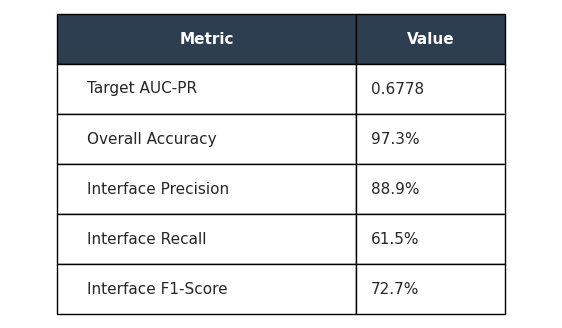

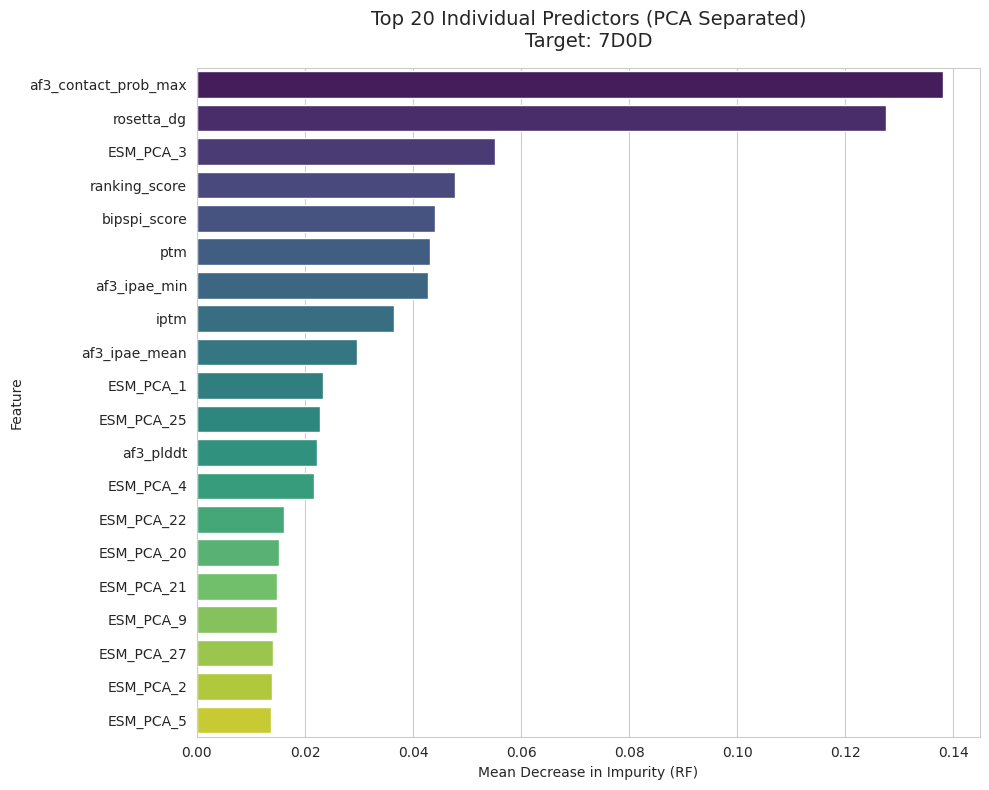

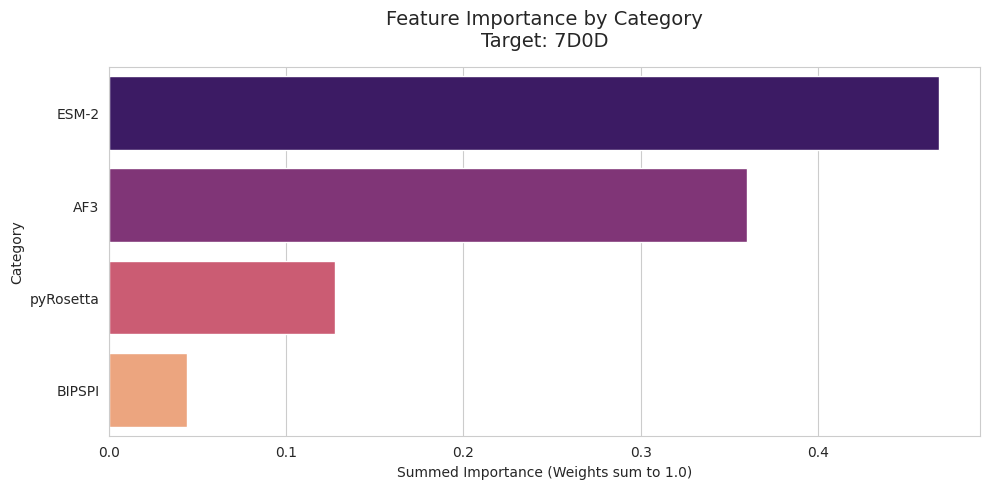


✅ ANALYSIS COMPLETE FOR 7D0D
📊 Metrics: Performance_Final_7D0D.png
📊 Individual Imp: Individual_Importance_Detailed_7D0D.png
📊 Category Imp: Category_Importance_7D0D.png


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (auc, roc_auc_score, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)

# ==========================================
# 1. SETUP & TARGET SELECTION
# ==========================================
TARGET_COMPLEX = "7D0D"
BASE_PATH = '/content/drive/Shared drives/CMU Zymo Capstone S26'
# Ensure this path matches your labeled integrated CSV
CSV_PATH = os.path.join(BASE_PATH, "FINAL_TRAINING_DATA_WITH_LABELS.csv")
NPY_PATH = os.path.join(BASE_PATH, "esm2_embeddings_650M.npy")

print(f"📂 Loading data for Targeted Validation on {TARGET_COMPLEX}...")
df = pd.read_csv(CSV_PATH)
raw_esm = np.load(NPY_PATH)

# Feature Definitions
af3_local = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max']
af3_global = ['iptm', 'ptm', 'ranking_score']
bio_feats = ['rosetta_dg', 'bipspi_score']

feature_cols = af3_local + af3_global + bio_feats

# ==========================================
# 2. PREPROCESSING & PCA
# ==========================================
# Drop rows where ground truth or critical features are missing
mask = df['ground_truth'].notnull() & df['af3_plddt'].notnull()
df_c = df[mask].copy()
esm_c = raw_esm[mask]

# Normalize Numerical Features
scaler = StandardScaler()
df_c[feature_cols] = scaler.fit_transform(df_c[feature_cols])

print(f"🧬 Reducing ESM-2 to 32 Dimensions...")
pca = PCA(n_components=32, random_state=42)
esm_pca = pca.fit_transform(esm_c)
esm_labels = [f'ESM_PCA_{i+1}' for i in range(32)]

X = np.hstack([df_c[feature_cols].values, esm_pca])
y = df_c['ground_truth'].astype(int).values
complex_ids = df_c['complex_id'].values
all_feat_names = feature_cols + esm_labels

# Split: Train on everyone EXCEPT the target complex
train_mask = (complex_ids != TARGET_COMPLEX)
test_mask = (complex_ids == TARGET_COMPLEX)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ==========================================
# 3. ENSEMBLE TRAINING
# ==========================================
print(f"🚀 Training Ensemble Model with {len(feature_cols)} features + ESM-2...")
rf = RandomForestClassifier(n_estimators=250, max_depth=10, class_weight='balanced', random_state=42)
gbm = HistGradientBoostingClassifier(max_iter=250, max_depth=5, l2_regularization=15.0, random_state=42)

rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)

# Ensemble Prediction
ensemble_probs = (rf.predict_proba(X_test)[:, 1] + gbm.predict_proba(X_test)[:, 1]) / 2

# ==========================================
# 4. METRIC CALCULATION & OPTIMIZATION
# ==========================================
# Find optimal threshold to maximize F1 on the test set
p, r, t = precision_recall_curve(y_test, ensemble_probs)
pr_auc = auc(r, p)
f1_array = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
best_threshold = t[np.argmax(f1_array[:-1])]
y_pred = (ensemble_probs >= best_threshold).astype(int)

metrics_data = [
    ["Target AUC-PR", f"{pr_auc:.4f}"],
    ["Overall Accuracy", f"{accuracy_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Precision", f"{precision_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Recall", f"{recall_score(y_test, y_pred)*100:.1f}%"],
    ["Interface F1-Score", f"{f1_score(y_test, y_pred)*100:.1f}%"]
]

# ==========================================
# 5. VISUALIZATION: TABLE & DUAL IMPORTANCE
# ==========================================

# --- CHART 1: PERFORMANCE TABLE ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.axis('off')
table = ax.table(cellText=metrics_data, colLabels=["Metric", "Value"], loc='center', cellLoc='left', colWidths=[0.5, 0.25])
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.1, 3.0)
for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
plt.savefig(f'Performance_Final_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# --- DATA PREP FOR IMPORTANCE ---
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})

# Mapping categories as requested
category_map = {
    'AF3': af3_local + af3_global,
    'ESM-2': esm_labels,
    'pyRosetta': ['rosetta_dg'],
    'BIPSPI': ['bipspi_score']
}

# Calculate Categorical Importance
cat_data = []
for cat_name, feat_list in category_map.items():
    total_imp = fi_df[fi_df['Feature'].isin(feat_list)]['Importance'].sum()
    cat_data.append({'Category': cat_name, 'Total Importance': total_imp})
cat_fi_df = pd.DataFrame(cat_data).sort_values('Total Importance', ascending=False)

# --- CHART 2: TOP 20 INDIVIDUAL FEATURES (PCA SEPARATED) ---
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
top_20_fi = fi_df.sort_values('Importance', ascending=False).head(20)
sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
plt.title(f'Top 20 Individual Predictors (PCA Separated)\nTarget: {TARGET_COMPLEX}', fontsize=14, pad=15)
plt.xlabel('Mean Decrease in Impurity (RF)')
plt.tight_layout()
plt.savefig(f'Individual_Importance_Detailed_{TARGET_COMPLEX}.png', dpi=300)

# --- CHART 3: CATEGORICAL IMPORTANCE ---
plt.figure(figsize=(10, 5))
sns.barplot(x='Total Importance', y='Category', data=cat_fi_df, palette='magma')
plt.title(f'Feature Importance by Category\nTarget: {TARGET_COMPLEX}', fontsize=14, pad=15)
plt.xlabel('Summed Importance (Weights sum to 1.0)')
plt.tight_layout()
plt.savefig(f'Category_Importance_{TARGET_COMPLEX}.png', dpi=300)

plt.show()

print("\n" + "="*40)
print(f"✅ ANALYSIS COMPLETE FOR {TARGET_COMPLEX}")
print(f"📊 Metrics: Performance_Final_{TARGET_COMPLEX}.png")
print(f"📊 Individual Imp: Individual_Importance_Detailed_{TARGET_COMPLEX}.png")
print(f"📊 Category Imp: Category_Importance_{TARGET_COMPLEX}.png")
print("="*40)